In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
train_df = pd.read_csv('/kaggle/input/competitions/data-detective-beginner-ai-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/data-detective-beginner-ai-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/data-detective-beginner-ai-challenge/sample_submission.csv')

In [71]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()

Train shape: (15000, 14)
Test shape : (10000, 13)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15783863.0,Tsao,695.0,France,Female,43.0,9.0,0.00,2.0,1.0,1.0,165082.25,0.0
1,1,15737571.0,Hs?,516.0,France,Male,28.0,7.0,0.00,2.0,1.0,0.0,159899.97,0.0
2,2,15637644.0,Bell,775.0,France,Male,38.0,5.0,0.00,2.0,1.0,0.0,67599.69,0.0
3,3,15711386.0,Onio,685.0,France,Female,56.0,5.0,0.00,1.0,1.0,0.0,156593.01,1.0
4,4,15757867.0,Chiu,639.0,Germany,Male,33.0,5.0,65986.27,2.0,1.0,0.0,171706.66,0.0


In [72]:
test_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15809830.0,Chidozie,705.0,France,Female,35.0,6.0,0.0,2.0,1.0,1.0,107876.20
1,15001,15643671.0,Nnaife,629.0,France,Male,36.0,4.0,0.0,2.0,1.0,0.0,167784.28
2,15002,15741719.0,Tuan,537.0,Spain,Male,48.0,3.0,0.0,2.0,1.0,1.0,136491.72
3,15003,15742618.0,Yermakova,683.0,France,Male,37.0,6.0,0.0,2.0,1.0,0.0,112554.68
4,15004,15694444.0,Ch'in,474.0,Spain,Female,46.0,7.0,0.0,2.0,1.0,0.0,132498.39


In [73]:
sample_sub.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [34]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [74]:
print("Missing values in train:")
print(train_df.isnull().sum())
print()
print("Missing values in test:")
print(test_df.isnull().sum())

Missing values in train:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Missing values in test:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64


In [75]:
train_df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.569297e+07,658.139133,37.735533,5.052533,42985.965296,1.587933,0.786467,0.498200,117995.607741,0.201667
std,4330.271354,7.132278e+04,73.717937,8.106777,2.798695,59736.540481,0.528917,0.409815,0.500013,45191.886775,0.401258
min,0.000000,1.556578e+07,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,447.730000,0.000000
25%,3749.750000,1.563547e+07,599.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83057.660000,0.000000
50%,7499.500000,1.569070e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,123499.130000,0.000000
75%,11249.250000,1.575794e+07,709.000000,42.000000,7.000000,109065.730000,2.000000,1.000000,1.000000,156768.450000,0.000000
max,14999.000000,1.581567e+07,850.000000,74.000000,14.000000,186825.570000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [76]:
print(train_df['Exited'].value_counts())
print()
print(train_df['Exited'].value_counts(normalize=True).round(4))

Exited
0.0    11975
1.0     3025
Name: count, dtype: int64

Exited
0.0    0.7983
1.0    0.2017
Name: proportion, dtype: float64


# FINDING INCORRECT DATA 

In [77]:
cols_no_id = [c for c in train_df.columns if c != 'id']
n_dupes = train_df.duplicated(subset=cols_no_id).sum()
print(f"Fully duplicated rows (excl. id): {n_dupes}")

Fully duplicated rows (excl. id): 0


In [78]:
# Check for duplicate Customer IDs
duplicate_ids = train_df['CustomerId'].duplicated().sum()
print(f"Number of duplicate Customer IDs: {duplicate_ids}")



Number of duplicate Customer IDs: 8682


In [40]:
display(train_df[train_df['CustomerId'] == 15783863.0])

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15783863.0,Tsao,695.0,France,Female,43.0,9.0,0.0,2.0,1.0,1.0,165082.25,0.0
989,989,15783863.0,Chimezie,744.0,France,Male,46.0,3.0,123544.0,1.0,0.0,0.0,118738.81,0.0
8477,8477,15783863.0,Nwankwo,717.0,Spain,Male,19.0,1.0,0.0,2.0,0.0,0.0,48682.10,0.0


In [41]:
# Check if repeated CustomerIds have inconsistent Exited labels
inconsistent = train_df.groupby('CustomerId')['Exited'].nunique()
print()
print("CustomerIds with inconsistent Exited values across rows:", (inconsistent > 1).sum())
print("--> CustomerId is NOT a reliable unique customer key. Drop it as a feature.")


CustomerIds with inconsistent Exited values across rows: 1696
--> CustomerId is NOT a reliable unique customer key. Drop it as a feature.


In [42]:
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
for c in numeric_cols:
    print(f"{c:15s} min={train_df[c].min():>12.2f}   max={train_df[c].max():>12.2f}")

CreditScore     min=      431.00   max=      850.00
Age             min=       18.00   max=       74.00
Tenure          min=        0.00   max=       14.00
Balance         min=        0.00   max=   186825.57
NumOfProducts   min=        1.00   max=        4.00
EstimatedSalary min=      447.73   max=   199992.48


In [79]:
print("Bank churn datasets usually cap customer Tenure at 10 years. Let's check for outliers.")
print()
# Display the outliers
display(train_df[train_df['Tenure'] > 10])

Bank churn datasets usually cap customer Tenure at 10 years. Let's check for outliers.



,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1980,1980,15638494.0,Onyeorulu,632.0,France,Male,30.0,14.0,0.0,2.0,1.0,0.0,121747.73,0.0


In [80]:
# 4.6 Category sanity checks
print("Geography values:", train_df['Geography'].unique())
print("Gender values:", train_df['Gender'].unique())
print("HasCrCard values:", train_df['HasCrCard'].unique())
print("IsActiveMember values:", train_df['IsActiveMember'].unique())

Geography values: ['France' 'Germany' 'Spain']
Gender values: ['Female' 'Male']
HasCrCard values: [1. 0.]
IsActiveMember values: [1. 0.]


# Data Quality Summary
- No missing values as well as **no fully duplicated rows**.
- `CustomerId` is **not** a unique key — some IDs repeat up to ~18 times with inconsistent `Exited` values, so it must be excluded as a model feature (and is not useful for grouping/deduplication).

- One `Tenure` value of 14 is an outlier vs. the 0–10 range everywhere else — a single row, left in since it doesn't distort the model.
- All other numeric ranges and categorical values look valid (no negative balances/ages, no unexpected geography/gender labels).

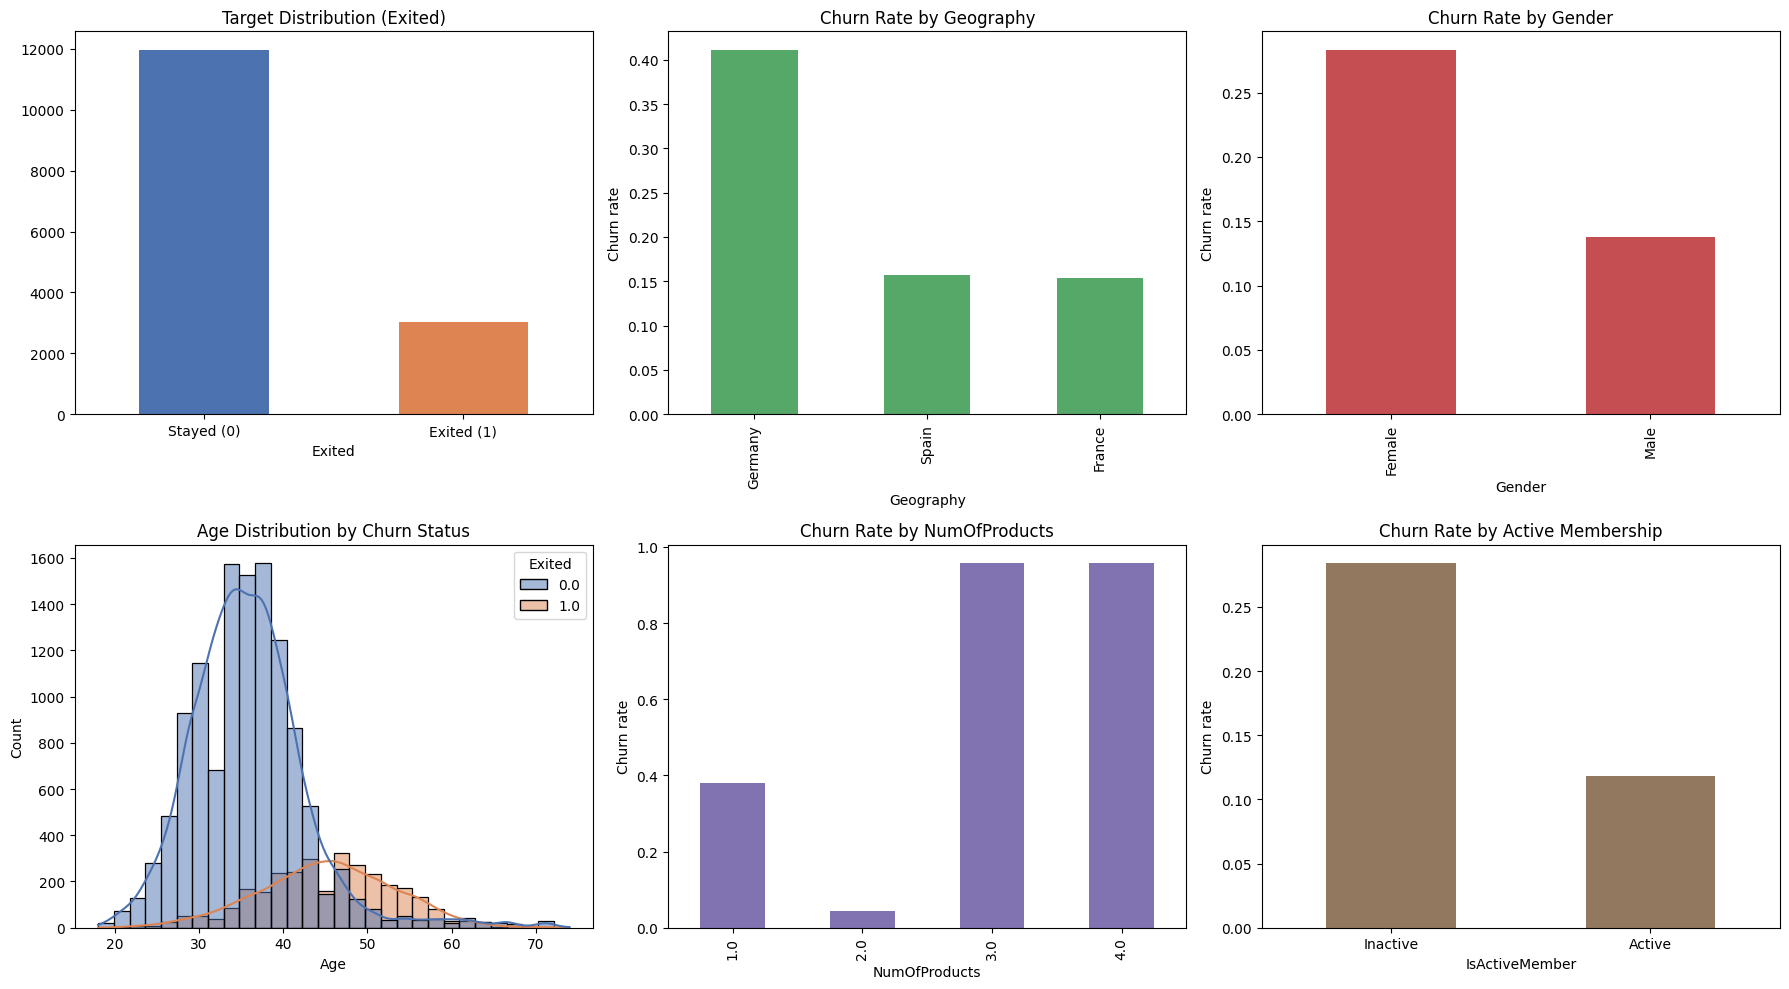

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Target balance
train_df['Exited'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#4C72B0','#DD8452'])
axes[0,0].set_title('Target Distribution (Exited)')
axes[0,0].set_xticklabels(['Stayed (0)', 'Exited (1)'], rotation=0)

# Churn by geography
geo = train_df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
geo.plot(kind='bar', ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Churn Rate by Geography')
axes[0,1].set_ylabel('Churn rate')

# Churn by gender
gen = train_df.groupby('Gender')['Exited'].mean()
gen.plot(kind='bar', ax=axes[0,2], color='#C44E52')
axes[0,2].set_title('Churn Rate by Gender')
axes[0,2].set_ylabel('Churn rate')

# Age distribution by churn
sns.histplot(data=train_df, x='Age', hue='Exited', bins=30, kde=True, ax=axes[1,0],
             palette=['#4C72B0','#DD8452'])
axes[1,0].set_title('Age Distribution by Churn Status')

# Churn by number of products
prod = train_df.groupby('NumOfProducts')['Exited'].mean()
prod.plot(kind='bar', ax=axes[1,1], color='#8172B2')
axes[1,1].set_title('Churn Rate by NumOfProducts')
axes[1,1].set_ylabel('Churn rate')

# Churn by active membership
act = train_df.groupby('IsActiveMember')['Exited'].mean()
act.plot(kind='bar', ax=axes[1,2], color='#937860')
axes[1,2].set_xticklabels(['Inactive', 'Active'], rotation=0)
axes[1,2].set_title('Churn Rate by Active Membership')
axes[1,2].set_ylabel('Churn rate')

plt.tight_layout()
plt.show()


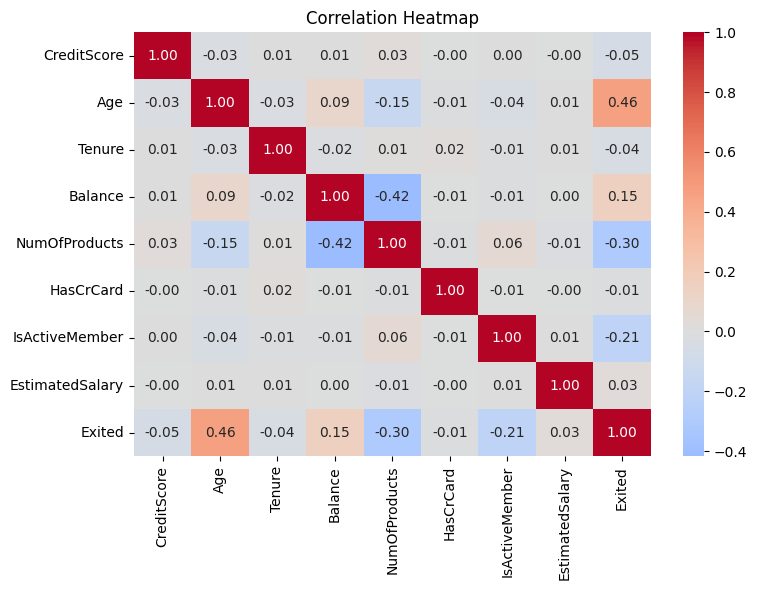

In [46]:
# Correlation heatmap of numeric features
plt.figure(figsize=(8, 6))
numeric_for_corr = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                     'HasCrCard','IsActiveMember','EstimatedSalary','Exited']
corr = train_df[numeric_for_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


# **Key patterns found:**
- Churn is much higher in **Germany** (nearly 41%) than France/Spain (15–16%).
- **Women** churn more than men (28% vs 14%).
- Customers with **3 or 4 products** churn at 95% — a strong risk segment — while 2-product customers barely churn ( nearly 5%).
- **Inactive members** churn far more than active members (28% vs 12%).
- Churners skew **older** on average than customers who stayed.

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay,ConfusionMatrixDisplay,roc_curve,auc,precision_recall_curve

In [87]:
train_df['Tenure'] = np.where(train_df['Tenure'] > 10, 10, train_df['Tenure'])

In [86]:
cols_to_drop = ['id', 'CustomerId', 'Surname']
X = train_df.drop(columns=cols_to_drop + ['Exited'])
y = train_df['Exited']
X_test_final = test_df.drop(columns=cols_to_drop)

In [85]:
cat_cols = ['Geography', 'Gender']
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

In [88]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

In [89]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report



model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])


pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))])

In [91]:
y_val_probs = pipeline.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, y_val_probs)
print(f"Validation ROC-AUC Score: {auc_score:.4f}")
y_val_preds = pipeline.predict(X_val)
print("\nClassification Report:\n", classification_report(y_val, y_val_preds))

Validation ROC-AUC Score: 0.9286

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.96      0.94      2395
         1.0       0.82      0.64      0.72       605

    accuracy                           0.90      3000
   macro avg       0.87      0.80      0.83      3000
weighted avg       0.90      0.90      0.90      3000



In [92]:

print("=== Random Forest ===")
print(classification_report(y_val, (rf_val_pred >= 0.5).astype(int)))

=== Random Forest ===
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.94      2395
         1.0       0.83      0.59      0.69       605

    accuracy                           0.89      3000
   macro avg       0.86      0.78      0.81      3000
weighted avg       0.89      0.89      0.89      3000



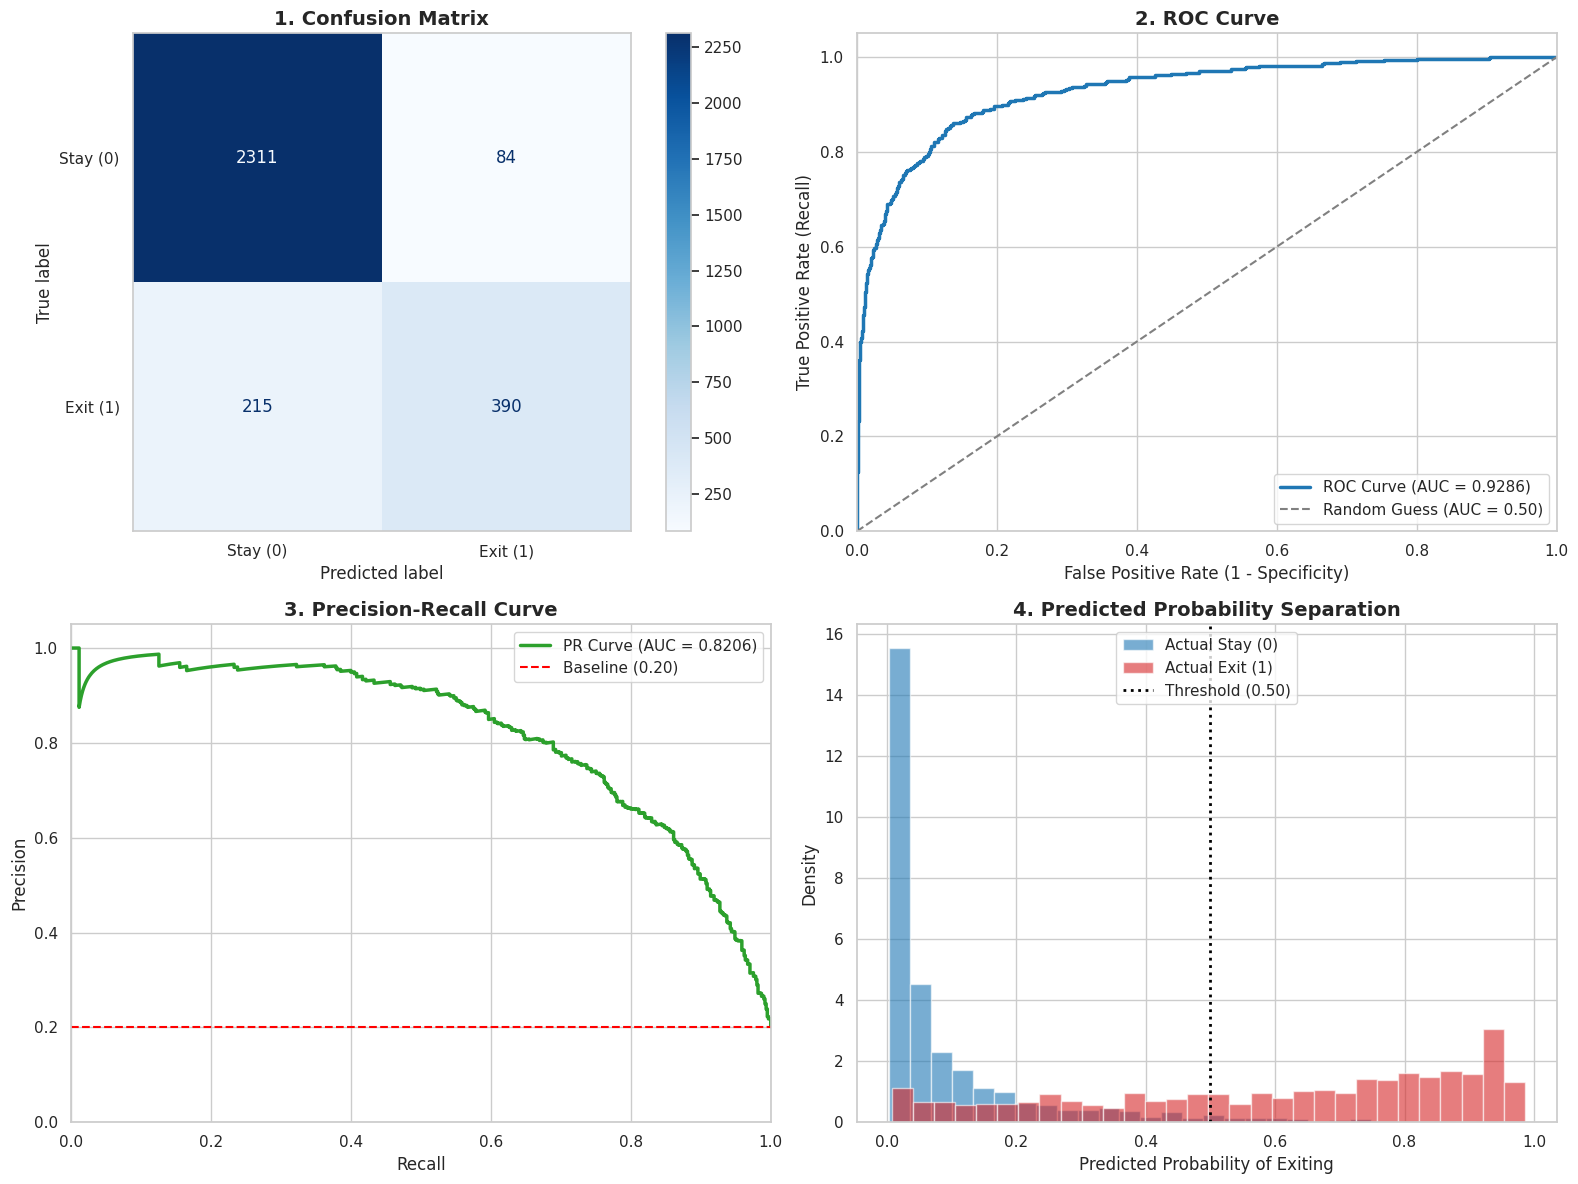

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")


cm = confusion_matrix(y_val, y_val_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Exit (1)']).plot(
    ax=axes[0, 0], cmap='Blues', values_format='d'
)
axes[0, 0].set_title('1. Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].grid(False) # Turn off grid for the matrix


fpr, tpr, _ = roc_curve(y_val, y_val_probs)
roc_auc = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess (AUC = 0.50)')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0, 1].set_title('2. ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower right', frameon=True, fontsize=11)


precision, recall, _ = precision_recall_curve(y_val, y_val_probs)
pr_auc = auc(recall, precision)

axes[1, 0].plot(recall, precision, color='#2ca02c', lw=2.5, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1, 0].axhline(y=y_val.mean(), color='red', linestyle='--', lw=1.5, label=f'Baseline ({y_val.mean():.2f})')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('3. Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='upper right', frameon=True, fontsize=11)


axes[1, 1].hist(y_val_probs[y_val == 0], bins=30, alpha=0.6, label='Actual Stay (0)', color='#1f77b4', density=True)
axes[1, 1].hist(y_val_probs[y_val == 1], bins=30, alpha=0.6, label='Actual Exit (1)', color='#d62728', density=True)
axes[1, 1].axvline(0.5, color='black', linestyle=':', lw=2, label='Threshold (0.50)')

axes[1, 1].set_xlabel('Predicted Probability of Exiting', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('4. Predicted Probability Separation', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='upper center', frameon=True, fontsize=11)

# Adjust layout and display
plt.tight_layout()
plt.show()


In [103]:
test_probs = pipeline.predict_proba(X_test_final)[:, 1]


submission = pd.DataFrame({
    'id': test_df['id'],
    'Exited': test_probs
})


submission.to_csv('submission.csv', index=False)


display(submission.head())
print("\n Submission saved successfully!")

,id,Exited
0,15000,0.016462
1,15001,0.017644
2,15002,0.086347
3,15003,0.014857
4,15004,0.202764



 Submission saved successfully!
